# 02. ROSE and LROM Cross Section Comparison

In [3]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom_legacy").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import benchmark_helper
import lrom_legacy.v2_0 as lrom

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})


## 1. System Setup 

In [4]:
TARGET = (40, 20)
PROJECTILE = (1, 0)
LAB_ENERGY = 14.1
L_MAX = 3
MESH_SIZE = 600
N_TRAIN = 200
N_TEST = 100
HALF_WIDTH = 0.20
ANGLES_DEG = np.arange(1.0, 180.0, 1.0)
BASIS_SIZES = (4, 6, 8)
ROSE_EIM_SIZES = (4, 8, 12)
LROM_PREDICTOR_COUNTS = (4, 8, 12)
DEFAULT_BASIS_SIZE = 6
DEFAULT_COMPRESSION_SIZE = 8
TIMING_REPEATS = 3
TIMING_INNER_LOOPS = 20
SEED = 1204
ERROR_DENOMINATOR_FLOOR = 1e-12
PLOTTING_FLOOR = 1e-6
LS_LABEL = "LS-projected cross section"


## 2. Initializaton: Training and Testing Samples

In [26]:

# Initializing LROM
emulator = lrom.LROM(
    target=TARGET,
    projectile=PROJECTILE,
    lab_energy=LAB_ENERGY,
    l=tuple(range(L_MAX + 1)),
    potential="full_woods-saxon",
)

#Defining central value
central = dict(emulator.central_parameters)
ranges = {
    name: tuple(sorted(((1.0 - HALF_WIDTH) * value, (1.0 + HALF_WIDTH) * value))
    )
    for name, value in central.items()
}

# Generating samples with a HF fom
emulator.sampling(
    training_ranges=ranges,
    testing_ranges=ranges,
    training_size=N_TRAIN,
    testing_size=N_TEST,
    mesh_size=MESH_SIZE,
    strategy="latin_hypercube",
    seed=SEED,
    high_fidelity_solver="runge_kutta",
    solver_options={"rk_tols": (1e-9, 1e-9)},
)


In [ ]:


design = emulator.samples.design
parameter_names = emulator.parameter_names
train_rows = design.training.values.copy()
test_rows = design.testing.values.copy()
train_ids = design.training.case_ids
test_ids = design.testing.case_ids

train_cases = [
    {name: float(value) for name, value in zip(parameter_names, row)}
    for row in train_rows
]
test_cases = [
    {name: float(value) for name, value in zip(parameter_names, row)}
    for row in test_rows
]

assert train_rows.shape == (N_TRAIN, len(parameter_names))
assert test_rows.shape == (N_TEST, len(parameter_names))
assert not any(np.array_equal(a, b) for a in train_rows for b in test_rows)


## 3. LROM Predictor Locations

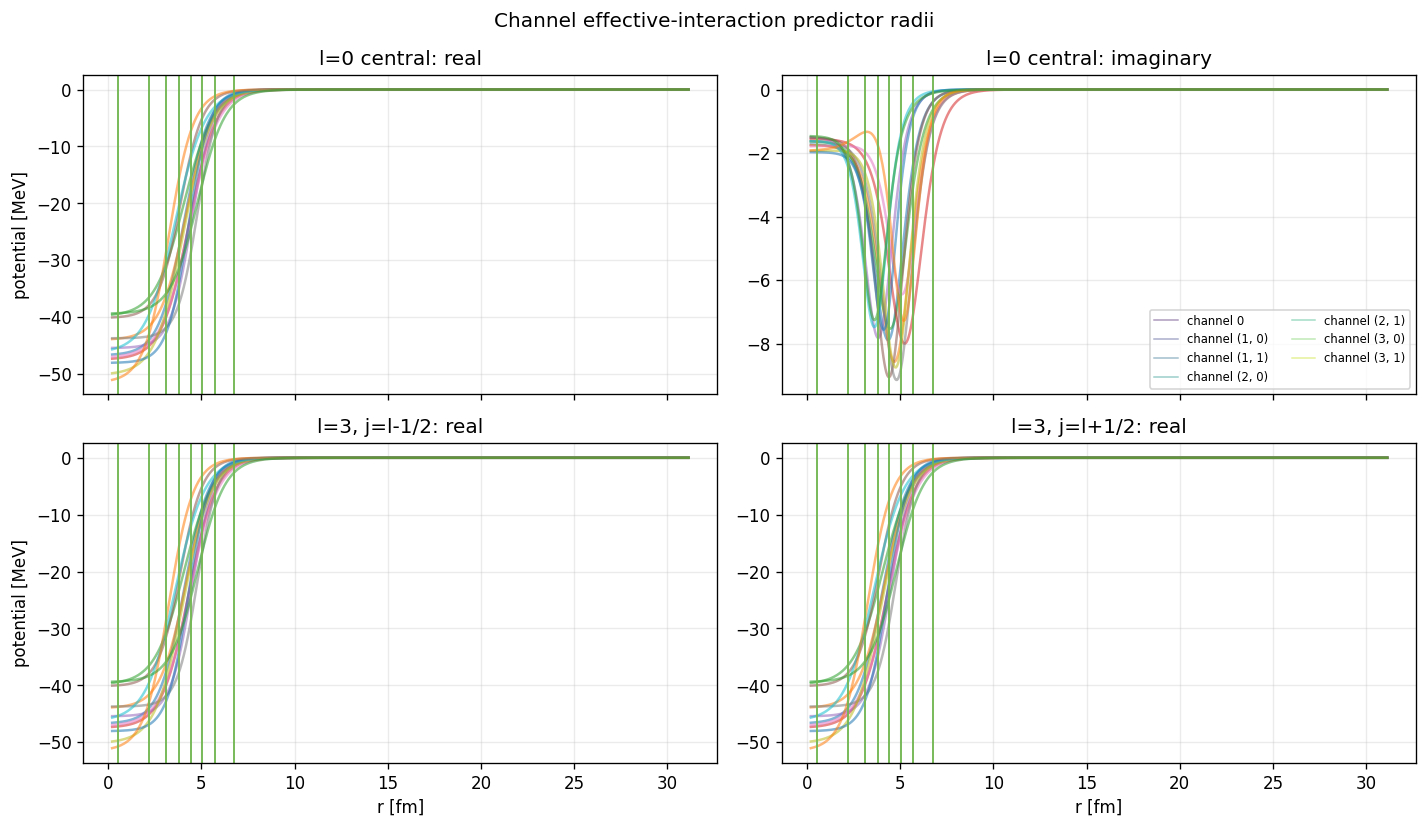

,channel,selected radii [fm]
0,0,"[0.5197, 2.1828, 3.1183, 3.794, 4.4177, 5.0413..."
1,"(1, 0)","[0.5197, 2.1828, 3.1183, 3.794, 4.4177, 5.0413..."
2,"(1, 1)","[0.5197, 2.1828, 3.1183, 3.794, 4.4177, 5.0413..."
3,"(2, 0)","[0.5197, 2.1828, 3.1183, 3.794, 4.4177, 5.0413..."
4,"(2, 1)","[0.5197, 2.1828, 3.1183, 3.794, 4.4177, 5.0413..."
5,"(3, 0)","[0.5197, 2.1828, 3.1183, 3.794, 4.4177, 5.0413..."
6,"(3, 1)","[0.5197, 2.1828, 3.1183, 3.794, 4.4177, 5.0413..."


In [7]:
mesh = emulator.samples.mesh
radius_mesh = mesh.radius
radius_mask = radius_mesh >= 0.2
plot_radius = radius_mesh[radius_mask]
center_vector = np.array([central[n] for n in parameter_names])

section3_predictor = lrom.build_effective_interaction_predictors(
    full_order_models=emulator.samples.full_order_models,
    rho=mesh.rho,
    radius=radius_mesh,
    central_values=center_vector,
    training_values=train_rows,
    testing_values=test_rows,
    predictor_count=DEFAULT_COMPRESSION_SIZE,
    minimum_radius=0.5,
)

range_scale = np.array([ranges[n][1] - ranges[n][0] for n in parameter_names])
ranked = np.argsort(np.linalg.norm((test_rows - center_vector) / range_scale, axis=1))
potential_rows = np.vstack(
    [center_vector, test_rows[ranked[np.linspace(0, len(ranked) - 1, 12, dtype=int)]]]
)

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), sharex=True)
for row in potential_rows:
    c = lrom.full_woods_saxon(radius_mesh, row)
    so = lrom.full_woods_saxon_spin_orbit(radius_mesh, row)
    for ax, curve in zip(
        axes.flat,
        [c.real, c.imag, (c - (L_MAX + 1) * so).real, (c + L_MAX * so).real],
    ):
        ax.plot(plot_radius, curve[radius_mask], alpha=0.55)

colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(section3_predictor)))
predictor_rows = []
for color, (channel, state) in zip(colors, section3_predictor.items()):
    for i, r in enumerate(state.selected_radii):
        for ax in axes.flat:
            ax.axvline(r, color=color, alpha=0.45, lw=0.9,
                       label=f"channel {channel}" if ax is axes[0, 1] and not i else None)
    predictor_rows.append({"channel": str(channel),
                           "selected radii [fm]": np.round(state.selected_radii, 4)})

for ax, title in zip(axes.flat, ["l=0 central: real", "l=0 central: imaginary",
                                 "l=3, j=l-1/2: real", "l=3, j=l+1/2: real"]):
    ax.set_title(title)
for ax in axes[1]:
    ax.set_xlabel("r [fm]")
for ax in axes[:, 0]:
    ax.set_ylabel("potential [MeV]")
axes[0, 1].legend(fontsize=7, ncol=2)
fig.suptitle("Channel effective-interaction predictor radii")
fig.tight_layout()

assert np.all(np.concatenate([s.selected_radii for s in section3_predictor.values()]) >= 0.5)
plt.show()
display(pd.DataFrame(predictor_rows))

## 4. ROSE, LS, and LROM Emulator pipeline

In [8]:
cross_section_benchmark = benchmark_helper.CrossSectionBenchmark(
    emulator=emulator,
    training_rows=train_rows,
    testing_rows=test_rows,
    angles_degrees=ANGLES_DEG,
    denominator_floor=ERROR_DENOMINATOR_FLOOR,
    timing_repeats=TIMING_REPEATS,
    timing_inner_loops=TIMING_INNER_LOOPS,
)

rose_comparison = cross_section_benchmark.run_rose(
    basis_sizes=BASIS_SIZES,
    eim_sizes=ROSE_EIM_SIZES,
)
ls_comparison = cross_section_benchmark.run_ls(
    basis_sizes=BASIS_SIZES,
    fom_training_cross_sections=rose_comparison.fom_training_cross_sections,
    fom_testing_cross_sections=rose_comparison.fom_testing_cross_sections,
    predictor_count=LROM_PREDICTOR_COUNTS[0],
)

rose_emulators = rose_comparison.emulators
reference_sae = rose_emulators[(BASIS_SIZES[0], ROSE_EIM_SIZES[0])]
fom_train_xs = rose_comparison.fom_training_cross_sections
fom_test_xs = rose_comparison.fom_testing_cross_sections
rose_results = rose_comparison.results
ls_results = ls_comparison.results
default_key = (DEFAULT_BASIS_SIZE, DEFAULT_COMPRESSION_SIZE)


LROM Pipeline

In [ ]:

# Training Emulator
emulator.train(
    basis_size=DEFAULT_BASIS_SIZE,
    predictor="potential",
    predictor_count=DEFAULT_COMPRESSION_SIZE,
    observable="cross_section",
    angles_degrees=ANGLES_DEG,
)

# Pro

emulator.predict(parameters=test_cases[:1], reconstruct_wavefunctions=False)
old_seconds = []
for case in test_cases:
    measurements = []
    for _ in range(TIMING_REPEATS):
        start = time.perf_counter_ns()
        for _ in range(TIMING_INNER_LOOPS):
            emulator.predict(parameters=case, reconstruct_wavefunctions=False)
        measurements.append(
            (time.perf_counter_ns() - start) / (1e9 * TIMING_INNER_LOOPS)
        )
    old_seconds.append(min(measurements))

emulator.predict(parameters=test_cases, reconstruct_wavefunctions=False)
old_test_xs = emulator.predictions.cross_sections.values.copy()
old_error = benchmark_helper.summarize_relative_error(
    old_test_xs,
    fom_test_xs,
    ERROR_DENOMINATOR_FLOOR,
)
old_v2_results = {
    default_key: {
        "test_xs": old_test_xs,
        "test_median_over_angle_error": old_error["median_over_angle_error"],
        "test_maximum_over_angle_error": old_error["maximum_over_angle_error"],
        "test_seconds": np.asarray(old_seconds),
    }
}


Varying basis size and number of predictors

In [10]:
lrom_results = {}
default_predictor = None

# Running a loop that follows the LROM pipeline, training for varying predictors and basis sizes

for n_phi in BASIS_SIZES:
    for predictor_count in LROM_PREDICTOR_COUNTS:
        key = (n_phi, predictor_count)
        emulator.train(
            basis_size=n_phi,
            predictor="effective-interaction",
            predictor_count=predictor_count,
            observable="cross_section",
            angles_degrees=ANGLES_DEG,
        )

        emulator.predict(parameters=test_cases[:1], reconstruct_wavefunctions=False)
        test_seconds = []
        for case in test_cases:
            reps = []
            for _ in range(TIMING_REPEATS):
                t0 = time.perf_counter_ns()
                for _ in range(TIMING_INNER_LOOPS):
                    emulator.predict(parameters=case, reconstruct_wavefunctions=False)
                reps.append((time.perf_counter_ns() - t0) / (1e9 * TIMING_INNER_LOOPS))
            test_seconds.append(min(reps))

        summary = {"test_seconds": np.asarray(test_seconds)}
        for tag, cases, fom_xs in (("train", train_cases, fom_train_xs),
                                   ("test", test_cases, fom_test_xs)):
            emulator.predict(parameters=cases, reconstruct_wavefunctions=False)
            xs = emulator.predictions.cross_sections.values.copy()
            err = benchmark_helper.summarize_relative_error(xs, fom_xs, ERROR_DENOMINATOR_FLOOR)
            summary[f"{tag}_xs"] = xs
            summary |= {f"{tag}_{k}": err[k]
                        for k in ("median_over_angle_error", "maximum_over_angle_error")}
        lrom_results[key] = summary

        if key == default_key:
            default_predictor = emulator.predictors

archive_lrom_results = lrom_results

# 
assert len(reference_sae.rbes) == L_MAX + 1
assert fom_train_xs.shape == (N_TRAIN, ANGLES_DEG.size)
assert fom_test_xs.shape == (N_TEST, ANGLES_DEG.size)
assert set(lrom_results) == {(n, p) for n in BASIS_SIZES for p in LROM_PREDICTOR_COUNTS}
assert set(rose_results) == {(n, u) for n in BASIS_SIZES for u in ROSE_EIM_SIZES}
assert default_predictor is not None and set(default_predictor) == set(section3_predictor)
assert (np.median(lrom_results[default_key]["test_median_over_angle_error"])
        < np.median(old_v2_results[default_key]["test_median_over_angle_error"]))

## 5. Cross Section Test Cases: examples/performance

In [11]:
lrom_error = lrom_results[default_key]["test_median_over_angle_error"]
rose_error = rose_results[default_key]["test_median_over_angle_error"]
lrom_rank = np.argsort(np.argsort(lrom_error))
rose_rank = np.argsort(np.argsort(rose_error))
ordered = np.argsort(0.5 * (lrom_rank + rose_rank))
positions = np.linspace(0, len(ordered) - 1, 5, dtype=int)[1:-1]
selected_indices = [int(ordered[position]) for position in positions]
selected_labels = (
    "alpha selection A",
    "alpha selection B",
    "alpha selection C",
)

alpha_cases = pd.DataFrame(
    [
        {
            "selection": label,
            "case_id": test_ids[index],
            **{
                name: float(test_rows[index, column])
                for column, name in enumerate(parameter_names)
            },
        }
        for label, index in zip(selected_labels, selected_indices)
    ]
)
#display(alpha_cases)


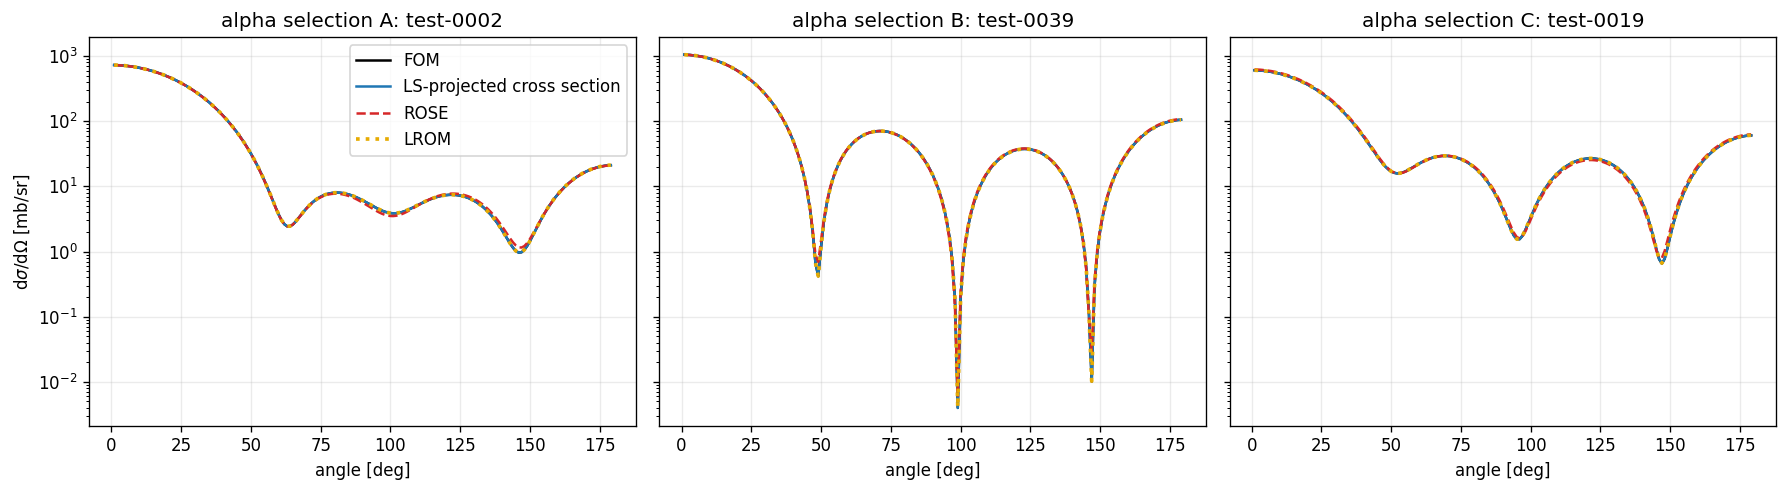

In [ ]:
fig, axes = plt.subplots(
    1,
    len(selected_indices),
    figsize=(15.0, 4.2),
    sharey=True,
)

for ax, index, label in zip(axes, selected_indices, selected_labels):
    ax.semilogy(ANGLES_DEG, fom_test_xs[index], color="black", label="FOM")
    ax.semilogy(
        ANGLES_DEG,
        ls_results[DEFAULT_BASIS_SIZE]["test_xs"][index],
        color="tab:blue",
        label=LS_LABEL,
    )
    ax.semilogy(
        ANGLES_DEG,
        rose_results[default_key]["test_xs"][index],
        "--",
        color="tab:red",
        label="ROSE",
    )
    ax.semilogy(
        ANGLES_DEG,
        lrom_results[default_key]["test_xs"][index],
        ":",
        color="#E6AB02",
        lw=2.2,
        label="LROM",
    )
    ax.set_title(f"{test_ids[index]}")#{label}: 
    ax.set_xlabel("angle [deg]")

axes[0].set_ylabel(r"d$\sigma$/d$\Omega$ [mb/sr]")
axes[0].legend()
fig.tight_layout()
plt.show()


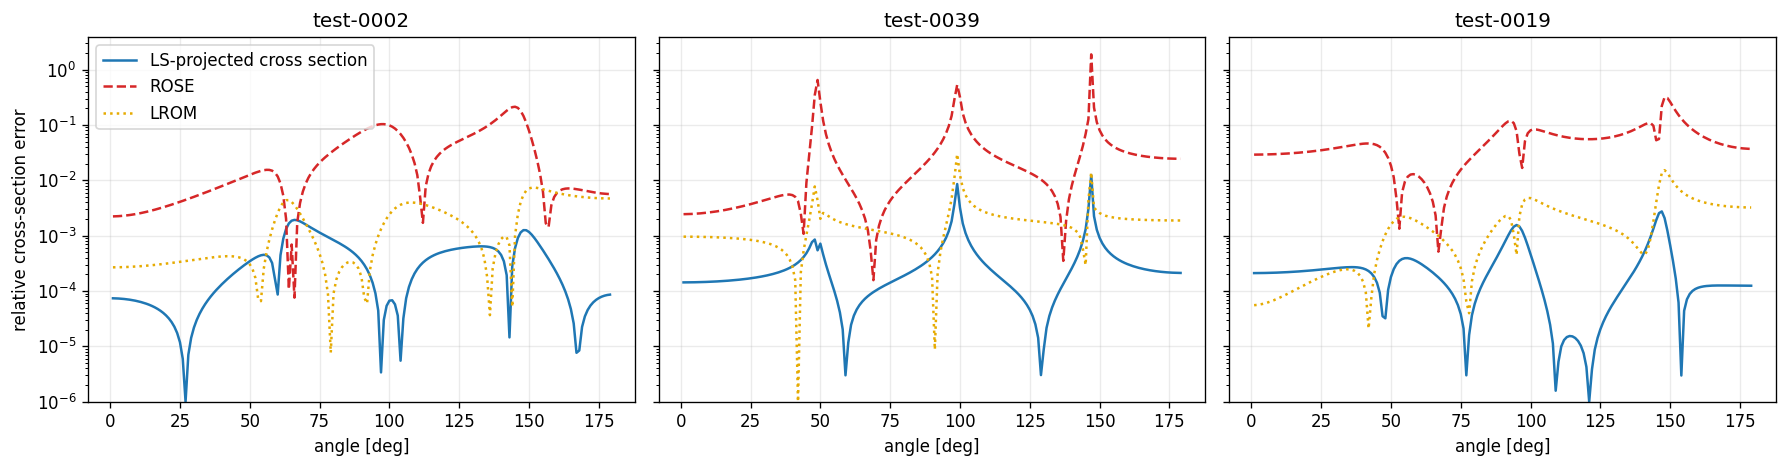

In [25]:
fig, axes = plt.subplots(
    1,
    len(selected_indices),
    figsize=(15.0, 4.0),
    sharey=True,
)

error_methods = (
    (
        ls_results[DEFAULT_BASIS_SIZE]["test_xs"],
        LS_LABEL,
        "tab:blue",
        "-",
    ),
    (rose_results[default_key]["test_xs"], "ROSE", "tab:red", "--"),
    (lrom_results[default_key]["test_xs"], "LROM", "#E6AB02", ":"),
)

for ax, index, label in zip(axes, selected_indices, selected_labels):
    for values, method, color, style in error_methods:
        errors = benchmark_helper.pointwise_relative_error(
            values[index],
            fom_test_xs[index],
            ERROR_DENOMINATOR_FLOOR,
        )
        ax.semilogy(
            ANGLES_DEG,
            np.maximum(errors, PLOTTING_FLOOR),
            style,
            color=color,
            label=method,
        )
    ax.set_title(f"{test_ids[index]}")#{label}: 
    ax.set_xlabel("angle [deg]")

axes[0].set_ylim(bottom=PLOTTING_FLOOR)
axes[0].set_ylabel("relative cross-section error")
axes[0].legend()
fig.tight_layout()
plt.show()


## 6. Cross-Section Error Distributions

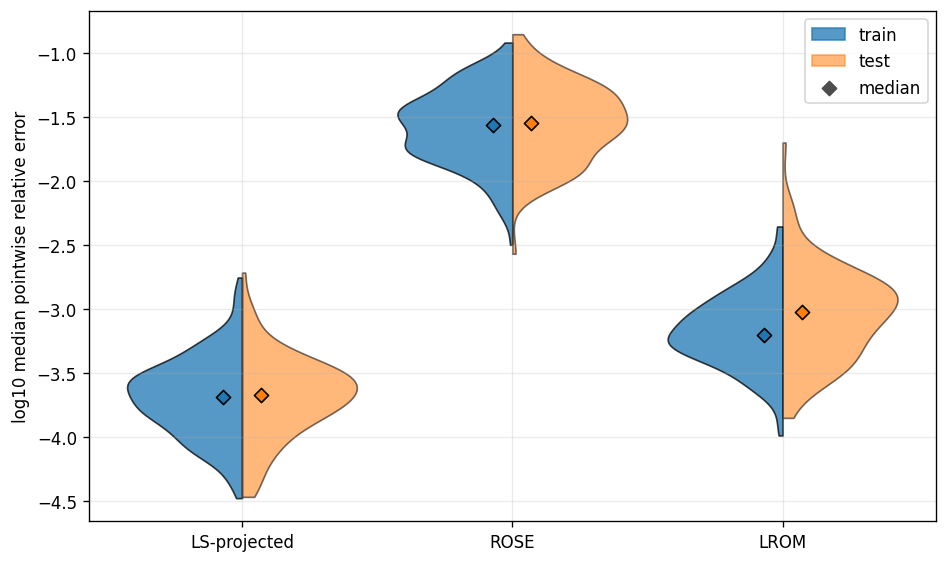

In [14]:
categories = (
    ("LS-projected", ls_results[DEFAULT_BASIS_SIZE]),
    ("ROSE", rose_results[default_key]),
    ("LROM", lrom_results[default_key]),
)
positions = np.arange(1, len(categories) + 1)
fig, ax = plt.subplots(figsize=(8.0, 4.8))

for center_position, (_, result) in zip(positions, categories):
    for side, key, color, opacity in (
        (-1, "train_median_over_angle_error", "tab:blue", 0.75),
        (+1, "test_median_over_angle_error", "tab:orange", 0.55),
    ):
        values = np.log10(np.clip(result[key], PLOTTING_FLOOR, None))
        parts = ax.violinplot(
            [values],
            positions=[center_position],
            widths=0.85,
            showextrema=False,
        )
        body = parts["bodies"][0]
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = (
            np.minimum(vertices[:, 0], center_position)
            if side < 0
            else np.maximum(vertices[:, 0], center_position)
        )
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(opacity)
        ax.scatter(
            center_position + 0.07 * side,
            np.median(values),
            marker="D",
            color=color,
            edgecolor="black",
            zorder=6,
        )

ax.set_xticks(positions, [label for label, _ in categories])
ax.set_ylabel("log10 median pointwise relative error")
ax.fill_between([], [], color="tab:blue", alpha=0.75, label="train")
ax.fill_between([], [], color="tab:orange", alpha=0.55, label="test")
ax.scatter([], [], marker="D", color="0.3", label="median")
ax.legend()
fig.tight_layout()
plt.show()


Producing summaries

In [23]:
summary_rows = []

for method, symbol, results in (
    ("ROSE", "n_U", rose_results),
    ("LROM", "K", lrom_results),
):
    for (n_phi, compression), result in results.items():
        summary_rows.append(
            {
                "method": method,
                "n_phi": n_phi,
                "compression symbol": symbol,
                "compression": compression,
                "median pointwise test error": float(
                    np.median(result["test_median_over_angle_error"])
                ),
                "median maximum-over-angle error": float(
                    np.median(result["test_maximum_over_angle_error"])
                ),
                "median online time [s]": float(
                    np.median(result["test_seconds"])
                ),
            }
        )

summary_table = pd.DataFrame(summary_rows).sort_values(
    ["method", "n_phi", "compression"]
)
#summary_table


## 7. CAT Plot

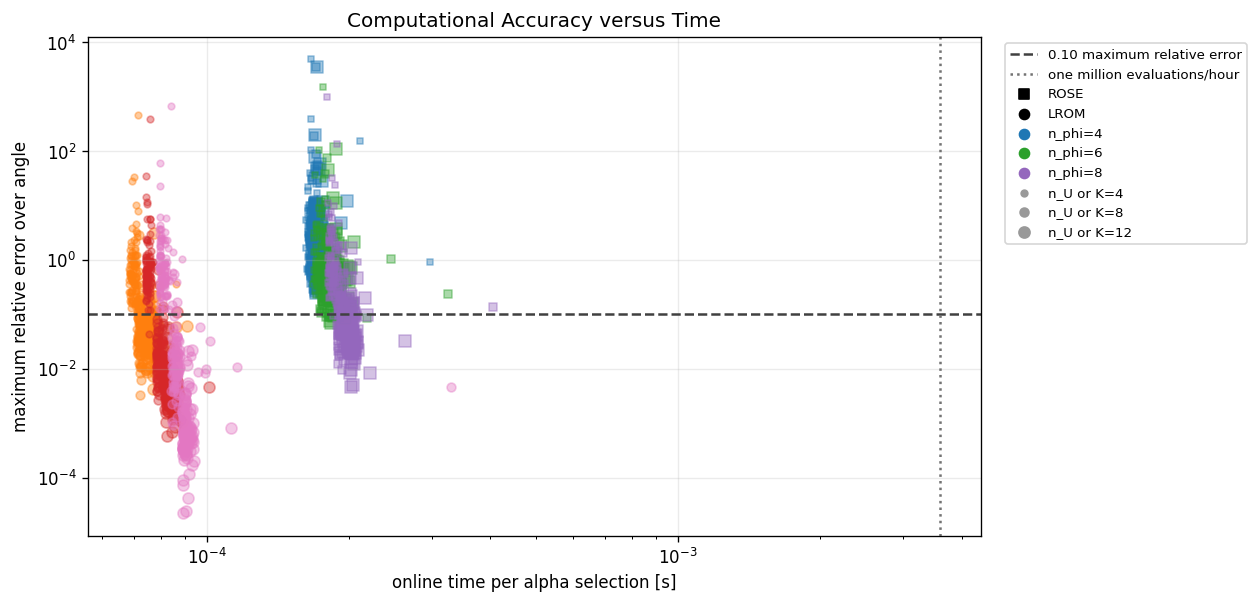

In [22]:
fig, ax = plt.subplots(figsize=(12.5, 5.4))
colors = dict(zip(BASIS_SIZES, ("tab:blue", "tab:green", "tab:purple")))
colors2 = dict(zip(BASIS_SIZES, ("tab:orange", "tab:red", "tab:pink")))
compression_values = ROSE_EIM_SIZES
compression_sizes = dict(zip(compression_values, (16, 28, 44)))

for (n_phi, n_u), result in rose_results.items():
    ax.scatter(
        result["test_seconds"],
        np.maximum(
            result["test_maximum_over_angle_error"],
            PLOTTING_FLOOR,
        ),
        marker="s",
        s=compression_sizes[n_u],
        alpha=0.4,
        color=colors[n_phi],
    )



for (n_phi, predictor_count), result in lrom_results.items():
    ax.scatter(
        result["test_seconds"],
        np.maximum(
            result["test_maximum_over_angle_error"],
            PLOTTING_FLOOR,
        ),
        marker="o",
        s=compression_sizes[predictor_count],
        alpha=0.4,
        color=colors2[n_phi],
    )

ax.axhline(
    0.10,
    color="0.25",
    linestyle="--",
    label="0.10 maximum relative error",
)
ax.axvline(
    3600 / 1_000_000,
    color="0.45",
    linestyle=":",
    label="one million evaluations/hour",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("online time per alpha selection [s]")
ax.set_ylabel("maximum relative error over angle")
ax.set_title("Computational Accuracy versus Time")

ax.scatter([], [], marker="s", color="black", label="ROSE")
ax.scatter([], [], marker="o", color="black", label="LROM")
for n_phi, color in colors.items():
    ax.scatter([], [], marker="o", color=color, label=f"n_phi={n_phi}")
for compression, size in compression_sizes.items():
    ax.scatter(
        [],
        [],
        marker="o",
        s=size,
        color="0.6",
        label=f"n_U or K={compression}",
    )

ax.legend(
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    fontsize=8,
)
fig.subplots_adjust(right=0.72)
plt.show()


validation_summary = pd.DataFrame(
    [
        {"check": "training rows", "value": train_rows.shape},
        {"check": "testing rows", "value": test_rows.shape},
        {"check": "ROSE/LROM shared rows", "value": True},
        {"check": "partial waves", "value": tuple(range(L_MAX + 1))},
        {"check": "parameter half-width", "value": HALF_WIDTH},
        {"check": "basis sizes", "value": BASIS_SIZES},
        {"check": "ROSE EIM sizes", "value": ROSE_EIM_SIZES},
        {
            "check": "LROM predictor counts",
            "value": LROM_PREDICTOR_COUNTS,
        },
        {
            "check": "LROM predictor method",
            "value": "effective-interaction",
        },
        {
            "check": "old v2 default median pointwise error",
            "value": float(
                np.median(
                    old_v2_results[default_key][
                        "test_median_over_angle_error"
                    ]
                )
            ),
        },
        {
            "check": "archive LROM default median pointwise error",
            "value": float(
                np.median(
                    archive_lrom_results[default_key][
                        "test_median_over_angle_error"
                    ]
                )
            ),
        },
        {"check": "LROM version", "value": lrom.__version__},
        {"check": "Python", "value": sys.version.split()[0]},
        {"check": "platform", "value": sys.platform},
    ]
)
validation_summary